Instalaciones

In [ ]:
# %pip install jenkspy
# %pip install scikit-posthocs


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importaciones

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Carga del Dataset

In [ ]:
df = pd.read_csv("../Data/data_cleaning_2026_27_04.csv")

In [6]:
df.columns

Index(['id', 'motivo_ausencia', 'mes_ausencia', 'dia_semana', 'estaciones',
       'gasto_transporte', 'distancia_casa_trabajo', 'tiempo_servicio', 'edad',
       'carga_trabajo_diaria', 'cumplimiento_objetivo', 'falta_disciplinaria',
       'educacion', 'hijos', 'bebedor_social', 'fumador_social', 'mascota',
       'peso', 'estatura', 'indice_masa_corporal', 'horas_ausentismo',
       'indicador_enfermedad', 'motivo_ausencia_mapeado',
       'mes_ausencia_mapeado', 'educacion_mapeada'],
      dtype='str')

Transformación de datos

In [7]:
df_clean = df.loc[:, ~df.columns.isin(['mascota', 'peso', 'estatura', 'bebedor_social', 'fumador_social'])]

In [8]:
df_clean = df_clean[df_clean['horas_ausentismo'] > 0]
df_clean.info()

<class 'pandas.DataFrame'>
Index: 757 entries, 0 to 805
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       757 non-null    int64  
 1   motivo_ausencia          757 non-null    int64  
 2   mes_ausencia             757 non-null    float64
 3   dia_semana               757 non-null    str    
 4   estaciones               757 non-null    str    
 5   gasto_transporte         757 non-null    int64  
 6   distancia_casa_trabajo   757 non-null    int64  
 7   tiempo_servicio          757 non-null    int64  
 8   edad                     757 non-null    int64  
 9   carga_trabajo_diaria     757 non-null    float64
 10  cumplimiento_objetivo    757 non-null    int64  
 11  falta_disciplinaria      757 non-null    int64  
 12  educacion                757 non-null    int64  
 13  hijos                    757 non-null    int64  
 14  indice_masa_corporal     757 non-null    i

## Tener hijos incide sul tiempo de ausencia?   
Tests no paramétricos
La variable horas_ausentismo presenta asimetría positiva (muchas ausencias cortas, pocas muy largas), por lo que no sigue distribución normal. Los tests paramétricos clásicos (t-test, ANOVA, Pearson) asumen normalidad y son sensibles a outliers — en este dataset darían resultados poco fiables. Se sustituyeron por sus equivalentes no paramétricos: Mann-Whitney U para comparar dos grupos.

In [9]:
from scipy import stats

con_hijos = df[df['hijos'] > 0]['horas_ausentismo']
sin_hijos = df[df['hijos'] == 0]['horas_ausentismo']

stat, p = stats.mannwhitneyu(con_hijos, sin_hijos, alternative='two-sided')
print(f"p-valor: {p:.4f}")
print("Diferencia significativa" if p < 0.05 else "Sin diferencia significativa")

print(f"\nMediana con hijos:  {con_hijos.median():.1f} h")
print(f"Mediana sin hijos:  {sin_hijos.median():.1f} h")

p-valor: 0.1380
Sin diferencia significativa

Mediana con hijos:  4.0 h
Mediana sin hijos:  3.0 h


## ¿El rango de edad influye en la duración de los episodios de ausencia?   
El rango de edad: el metodo para encontrar los cortes donde la variación dentro del grupo es mínima y entre grupos es máxima. Diseñado para agrupar una variable continua de forma objetiva: agrupación de edad con Jenks Natural Breaks  
Para aplicar Kruskal-Wallis, edad necesita convertirse en grupos discretos. Definir los cortes manualmente (ej. 18-30, 31-45...) introduce sesgo del analista: los resultados del test dependerían de una decisión arbitraria, no de la estructura real de los datos. Se evaluaron tres alternativas: rangos manuales (descartado por sesgo), KMeans (descartado porque está diseñado para espacios multidimensionales y es innecesariamente complejo para una sola variable), y Jenks Natural Breaks. Este último algoritmo encuentra los cortes donde la variación dentro de cada grupo es mínima y la variación entre grupos es máxima — es decir, los grupos resultantes son internamente homogéneos y externamente distintos. Es el método estándar en análisis de una variable continua cuando no se tiene conocimiento previo del dominio para justificar cortes específicos

In [10]:
import jenkspy
import scikit_posthocs as sp
from scipy import stats

# 1. Crear grupos de edad con Jenks Natural Breaks
breaks = jenkspy.jenks_breaks(df_clean['edad'], n_classes=4)
df_clean['rango_edad'] = pd.cut(df_clean['edad'], bins=breaks, include_lowest=True)

print("Distribución de grupos:")
print(df_clean['rango_edad'].value_counts().sort_index())

# 2. Kruskal-Wallis
grupos = [g['horas_ausentismo'].values
          for _, g in df_clean.groupby('rango_edad', observed=True)]

stat, p = stats.kruskal(*grupos)
print(f"\nKruskal-Wallis — p-valor: {p:.4f}")

# 3. Post-hoc Dunn solo si hay diferencia significativa
if p < 0.05:
    print("\nDiferencia significativa — test de Dunn (Bonferroni):")
    print(sp.posthoc_dunn(df_clean, val_col='horas_ausentismo',
                          group_col='rango_edad', p_adjust='bonferroni'))
else:
    print("Sin diferencia significativa entre grupos de edad.")

Distribución de grupos:
rango_edad
(26.999, 31.0]    212
(31.0, 36.0]      149
(36.0, 43.0]      309
(43.0, 58.0]       87
Name: count, dtype: int64

Kruskal-Wallis — p-valor: 0.0000

Diferencia significativa — test de Dunn (Bonferroni):
                (26.999, 31.0]  (31.0, 36.0]  (36.0, 43.0]  (43.0, 58.0]
(26.999, 31.0]    1.000000e+00  2.196447e-07  1.000000e+00  1.000000e+00
(31.0, 36.0]      2.196447e-07  1.000000e+00  2.116258e-07  3.044114e-07
(36.0, 43.0]      1.000000e+00  2.116258e-07  1.000000e+00  7.606020e-01
(43.0, 58.0]      1.000000e+00  3.044114e-07  7.606020e-01  1.000000e+00


## ¿A mayor carga de trabajo diaria, más horas de ausencia?

Coeficiente Spearman: 0.0460
p-valor: 0.2063
→ No se detecta relación significativa entre carga de trabajo y absentismo.


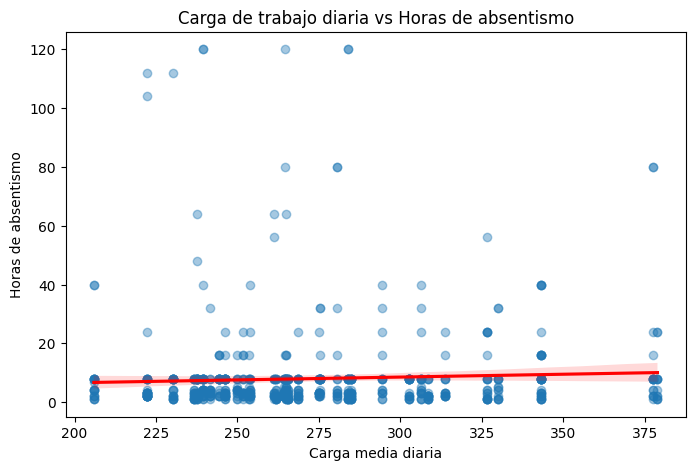

Distribución de grupos de carga:
grupo_carga
(205.916, 253.957]    317
(253.957, 284.853]    250
(284.853, 330.061]    124
(330.061, 378.884]     66
Name: count, dtype: int64

Kruskal-Wallis p-valor: 0.0090
→ Diferencias significativas entre grupos de carga.

Post-hoc Dunn (Bonferroni):
                    (205.916, 253.957]  (253.957, 284.853]  \
(205.916, 253.957]            1.000000            1.000000   
(253.957, 284.853]            1.000000            1.000000   
(284.853, 330.061]            1.000000            1.000000   
(330.061, 378.884]            0.027334            0.004394   

                    (284.853, 330.061]  (330.061, 378.884]  
(205.916, 253.957]            1.000000            0.027334  
(253.957, 284.853]            1.000000            0.004394  
(284.853, 330.061]            1.000000            0.039546  
(330.061, 378.884]            0.039546            1.000000  


In [11]:
# ------------------------------------------------------------
# 1. Test no paramétrico: Correlación de Spearman
# ------------------------------------------------------------
from scipy.stats import spearmanr

rho, pval = spearmanr(
    df_clean['carga_trabajo_diaria'],
    df_clean['horas_ausentismo']
)

print(f"Coeficiente Spearman: {rho:.4f}")
print(f"p-valor: {pval:.4f}")

if pval < 0.05:
    print("→ Relación monotónica significativa entre carga de trabajo y absentismo.")
else:
    print("→ No se detecta relación significativa entre carga de trabajo y absentismo.")

# ------------------------------------------------------------
# 2. Visualización: Scatterplot
# ------------------------------------------------------------
plt.figure(figsize=(8,5))
sns.regplot(
    data=df_clean,
    x='carga_trabajo_diaria',
    y='horas_ausentismo',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)
plt.title("Carga de trabajo diaria vs Horas de absentismo")
plt.xlabel("Carga media diaria")
plt.ylabel("Horas de absentismo")
plt.show()

# ------------------------------------------------------------
# 3. Agrupación de carga de trabajo (Jenks Natural Breaks)
# ------------------------------------------------------------
import jenkspy

breaks = jenkspy.jenks_breaks(
    df_clean['carga_trabajo_diaria'], 
    n_classes=4
)

df_clean['grupo_carga'] = pd.cut(
    df_clean['carga_trabajo_diaria'],
    bins=breaks,
    include_lowest=True
)

print("Distribución de grupos de carga:")
print(df_clean['grupo_carga'].value_counts().sort_index())

# ------------------------------------------------------------
# 4. Kruskal-Wallis entre grupos de carga
# ------------------------------------------------------------
from scipy.stats import kruskal
import scikit_posthocs as sp

grupos = [
    g['horas_ausentismo'].values
    for _, g in df_clean.groupby('grupo_carga', observed=True)
]

stat, p = kruskal(*grupos)
print(f"\nKruskal-Wallis p-valor: {p:.4f}")

if p < 0.05:
    print("→ Diferencias significativas entre grupos de carga.")
    print("\nPost-hoc Dunn (Bonferroni):")
    print(
        sp.posthoc_dunn(
            df_clean,
            val_col='horas_ausentismo',
            group_col='grupo_carga',
            p_adjust='bonferroni'
        )
    )
else:
    print("→ No se detectan diferencias significativas entre grupos de carga.")

Correlacion de Spearman
p = 0.0460
p-valor = 0.2063

no existe una relación monotónica significativa entre la carga de trabajo diaria y las horas de absentismo. En términos prácticos, los empleados con mayor carga diaria no presentan sistemáticamente más horas de ausencia.


Análisis por grupo
Se agruparon los empleados en cuatro rangos homogéneos de carga de trabajo.  
En el test de Kruskal-Wallis p-valor=0.0090 - indica diferencia significativa entre al menos dos grupos

Anális post-hoc Dunn con corrección Bonferroni (ajuste p-valor para evitar falso positivos) - diferencias se concentram en el grupo de carga más alta (330.061, 378.884), demás grupos con p-valor significativo (0.0273, 0.0044, 0.0395)

Conclusión:
- La carga de trabajo no afecta de forma lineal ni progresiva al absentismo
- Sin embargo, **niveles extremos de carga** sí podrían estar asociados a un aumento puntual de las horas de ausencia
- El aumento del ausentismo estaria concentrado en el grupo de mayor carga operativa.

C:\Users\anacl\AppData\Local\Temp\ipykernel_22252\2856563828.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


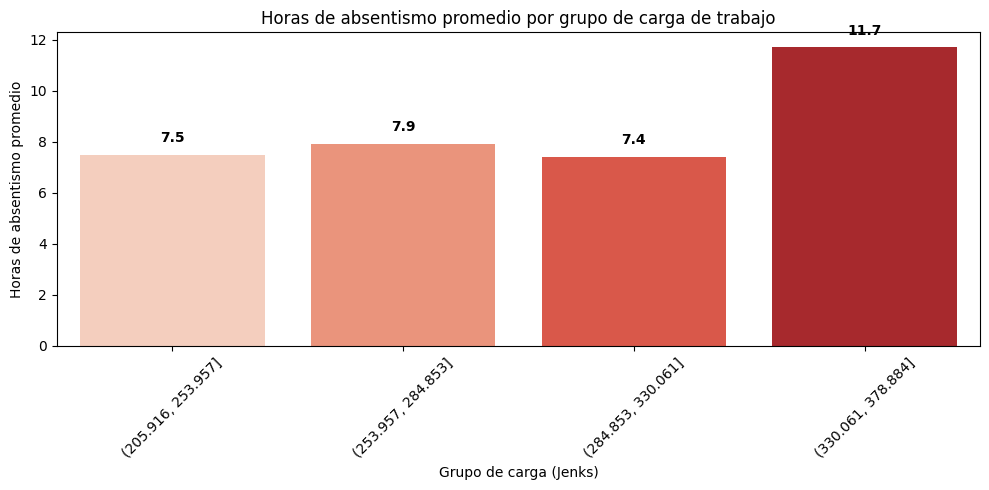

In [12]:
# ============================================================
# Gráfico de Barras: Media de horas de absentismo por grupo de carga
# ============================================================

plt.figure(figsize=(10,5))

# Calculamos la media de absentismo por grupo
media_abs = df_clean.groupby('grupo_carga')['horas_ausentismo'].mean()

sns.barplot(
    x=media_abs.index.astype(str),
    y=media_abs.values,
    palette="Reds"
)

plt.title("Horas de absentismo promedio por grupo de carga de trabajo")
plt.xlabel("Grupo de carga (Jenks)")
plt.ylabel("Horas de absentismo promedio")

# Añadimos etiquetas numéricas encima de cada barra
for i, v in enumerate(media_abs.values):
    plt.text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\anacl\AppData\Local\Temp\ipykernel_22252\2358689981.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


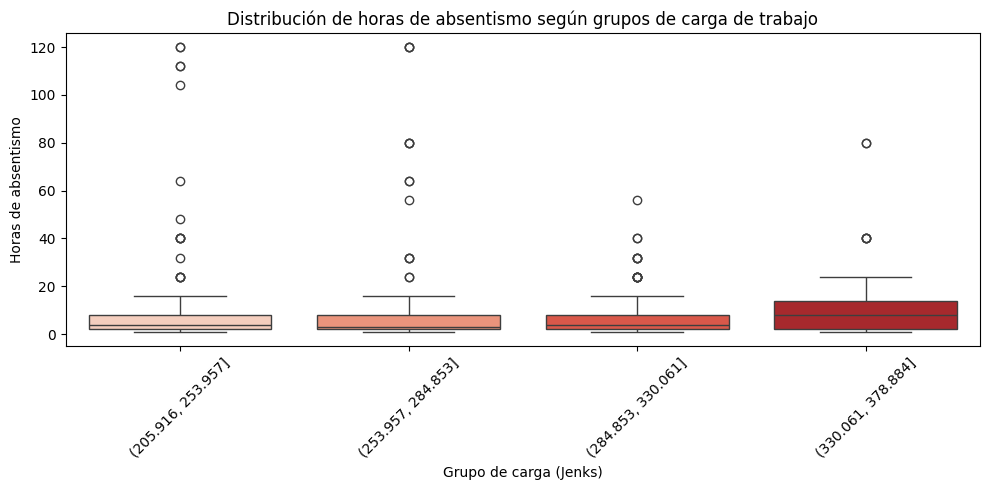

In [13]:
# ============================================================
# Boxplot Final: Horas de absentismo por grupo de carga
# ============================================================

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean,
    x='grupo_carga',
    y='horas_ausentismo',
    palette="Reds"
)

plt.title("Distribución de horas de absentismo según grupos de carga de trabajo")
plt.xlabel("Grupo de carga (Jenks)")
plt.ylabel("Horas de absentismo")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()